In [47]:
#set the environment variable for Groq API key
import os

if "GROQ_API_KEY" not in os.environ:
    print("Warning: GROQ_API_KEY environment variable not set")


In [48]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)


In [49]:
#llm schema for the evaluator eg: jokes funny or not

from pydantic import BaseModel,Field
from typing import List,Literal

class llm_schema(BaseModel):
    funny_flag : Literal["funny","not_funny"] = Field(description="Whether the joke is funny or not")
    feedback : str = Field(description="Feeback about the jokes to improve")

llm_with_schema = llm.with_structured_output(llm_schema)
response = llm_with_schema.invoke("Why do we tell actors to break a leg?  Because every play has a cast!")
print(response)


funny_flag='funny' feedback="The joke is funny and plays on the double meaning of the word 'cast'."


In [50]:
#Graph schema 
from typing import TypedDict,List
class Graph_schema(TypedDict):
    topic : str
    jokes: str
    funny_flag: []
    feedback: str
    max_iteration: int

Create a Node


In [51]:
#generate node takes the topic then generate the jokes if state has feedback  and max_iteration is less than 5 then regenerate the jokes until 5 iteration then end
from langchain_core.prompts import ChatPromptTemplate

def generate_node(state: Graph_schema) -> Graph_schema:

    topic = state["topic"]

    if state["feedback"] and (0<state["max_iteration"] < 5) :
        jokes = llm.invoke(f"Modify the jokes {state["jokes"]} on the basis of the feedback is {state["feedback"]}").content

    else:
        jokes = llm.invoke(f"create a jokes on the topic of {topic}").content

    #update jokes
    state["jokes"] = jokes

    return state


In [52]:
#create a evaluator node
#evaluator node analyze the jokes whether it is funny,not funny and also give feedback generated by generated node 

def evaluator_node(state: Graph_schema) -> Graph_schema:

    jokes = state["jokes"]
    iteration = state["max_iteration"]

    prompt = ChatPromptTemplate.from_messages([
        ("system","You are a gudge of the comedy show,your job is evaluate the joke and provide the feedback."),
        ("user","observe the joke: {jokes} and evaluate funny or not then provide the feedback")]
    )

    #define chain
    chain = prompt | llm_with_schema
    response = chain.invoke({"jokes":jokes})

    #update funny ,not funny and feedback
    state["funny_flag"] = response.funny_flag
    state["feedback"] = response.feedback
    state["max_iteration"] = iteration + 1

    return state



Now lets create a graph state and before that define a conditional edge


In [53]:
def condition_edge(state: Graph_schema) -> Graph_schema:

    max_iteration = state["max_iteration"]

    if state["feedback"] and max_iteration<5: 
        return "generate_node"

    else:
        return END

In [54]:
#create node and edges

from langgraph.graph import StateGraph,START,END

graph = StateGraph(Graph_schema)

#add nodes
graph.add_node("generate_node",generate_node)
graph.add_node("evaluator_node",evaluator_node)

#add edges
graph.add_edge(START,"generate_node")
graph.add_edge("generate_node","evaluator_node")
graph.add_conditional_edges("evaluator_node",condition_edge,{
    "generate_node": "generate_node",
    "end" : END
})
graph.add_edge("evaluator_node",END)



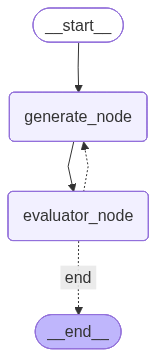

In [55]:
#compile the graph
from IPython.display import  display,Image

gen_evaluate_graph = graph.compile()
Image(gen_evaluate_graph.get_graph().draw_mermaid_png())

In [56]:
#invoke
gen_evaluate_graph.invoke({
    "topic": "Car",
    "jokes": "",
    "funny_flag" : [],
    "feedback" : "",
    "max_iteration" : 0

})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=llm_schema> {"funny_flag": "funny", "feedback": "The joke is funny because it\'s a play on words, using car-related puns to create a humorous effect. It\'s a lighthearted and silly joke that might make people chuckle. However, some people might find it cheesy or overused. Overall, it\'s a decent joke that could work well in a comedy setting.", "joke": "Here are a few car-themed jokes: 1. Why did the car go to the doctor? Because it was feeling a little "car-sick"! 2. Why did the car\'s GPS go to therapy? Because it was feeling a little "lost"! 3. What did the car say to the road? "You\'re always taking me for a ride!" 4. Why did the car\'s battery go to the doctor? Because it was feeling a little "drained"! 5. Why did the car go to the beauty

In [57]:
for chunk in gen_evaluate_graph.stream(
    { "topic": "Car",
    "jokes": "",
    "funny_flag" : [],
    "feedback" : "",
    "max_iteration" : 0

    
    },
    stream_mode = "updates"
):

    print(chunk)

{'generate_node': {'topic': 'Car', 'jokes': 'Here are a few car-themed jokes:\n\n1. Why did the car go to the doctor?\nBecause it was feeling a little "car-sick"!\n\n2. Why did the car\'s GPS go to therapy?\nBecause it was feeling a little "lost"!\n\n3. What did the car say to the road?\n"You\'re always taking me for a ride!"\n\n4. Why did the car go to the beauty parlor?\nBecause it wanted a new "tire" style!\n\n5. Why did the driver bring a ladder with him?\nBecause he wanted to take his driving to the next level!\n\n6. Why did the car\'s battery go to the party?\nBecause it was a "charged" atmosphere!\n\n7. Why did the driver put his car in the shower?\nBecause it was feeling a little "drained"!\n\n8. What do you call a car that\'s always making jokes?\nA "wheel"-good comedian!\n\n9. Why did the car go to the gym?\nTo get some "tire"-ing exercise!\n\n10. Why did the driver\'s car get kicked out of the bar?\nBecause it was making too many "exhaust"-ing jokes!', 'funny_flag': [], 'fee

KeyError: '__end__'